# Step 0: Import Packages

In [57]:
# Operational Packages
import numpy as np # Numerical calculations
import pandas as pd # Data handling

# Visualization Packages
import matplotlib.pyplot as plt # Lower-level graphics
import seaborn as sns # High-level graphics

# General Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit # Train test split for model building and Grid Search for tuning
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # Model Performance metrics
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix # Confusion Matrix

### Machine Learning Models

# Random Forest 
from sklearn.ensemble import RandomForestClassifier # Random Forest Classifier

# For saving Machine Learning Models once we fit them
import pickle

# Step 1: Exploratory Data Analysis (EDA)

In [58]:
# Load the dataset into a pandas dataframe and examine the first few rows
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [59]:
#examine the shape of the dataset
df.shape

(891, 12)

The dataset contains 891 rows and 12 columns, so 891 passengers with 12 chararcteristics describing each one of them.

In [60]:
#examine the columns of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [61]:
#examine the descriptive statistics of the dataset
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Some initial concerns about the data is that is that there are over 100 entries missing their age and around 700 entries are missing a cabin number, I will have to investigate that.

## Step 1a Examine the Missing Values

In [62]:
#check for missing values
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

There are 
* 177 missing entries for age
* 687 missing entries for cabin
* 2 missing entries for Embarked

### Age Missing Values

In [63]:
# Check for missing values under age
mask = df["Age"].isna()
age_missing = df[mask]
age_missing.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q


I wonder if you don't have your age not listed, if there is a correlation with not having your cabin listed as well?

In [64]:
# Check for missing values under Cabin
age_missing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177 entries, 5 to 888
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  177 non-null    int64  
 1   Survived     177 non-null    int64  
 2   Pclass       177 non-null    int64  
 3   Name         177 non-null    object 
 4   Sex          177 non-null    object 
 5   Age          0 non-null      float64
 6   SibSp        177 non-null    int64  
 7   Parch        177 non-null    int64  
 8   Ticket       177 non-null    object 
 9   Fare         177 non-null    float64
 10  Cabin        19 non-null     object 
 11  Embarked     177 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 18.0+ KB


There seems to be a very high correlation between missing cabin and missing age as of the 177 entries that are missing age 158 of them are also missing a cabin number

In [65]:
# What passengers classes are missing their age in the dataset?
age_missing["Pclass"].value_counts()

Pclass
3    136
1     30
2     11
Name: count, dtype: int64

As I suspected, 136 of the 177 the entries that are missing their age are 3rd class which may positively correlate with our target variable of Survived

In [66]:
age_missing["Survived"].value_counts(normalize=True)  

Survived
0    0.706215
1    0.293785
Name: proportion, dtype: float64

70% of those who do not have their age listed died, which indicates a positive correlation

In [67]:
177/891

0.19865319865319866

To handle the missing values for age, I will assign the missing values to the mean age of the dataset rounded to the nearest whole number. I choose this approach as dropping 177 entries of the dataset of 891 entries would remove around 20% of the data which is far too much data. 

I will also create a new column in the dataframe called Age_listed which will indicate whether the passenger had their age as a non-na value.

In [68]:
#Create the Age_listed column 

df["Age_listed"] = df["Age"].notna().astype(int)

df.head(5)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_listed
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


In [69]:
#Check that Age_listed has 177 entries for 0
df["Age_listed"].value_counts()

Age_listed
1    714
0    177
Name: count, dtype: int64

In [70]:
# assign the missing values to the mean age of the dataset rounded to the nearest whole number
df["Age"] = df["Age"].fillna(round(df["Age"].mean()))

df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_listed
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


In [71]:
#Check that all the missing values are gone
df["Age"].isna().sum()

0

### Cabin Missing Values

In [72]:
# Create a new dataframe containing the entries missing a value in Cabin
mask = df["Cabin"].isna()
cabins_missing = df[mask]

#Confirm there are 687 entries in the new dataframe
cabins_missing.shape

(687, 13)

I wonder wha

In [73]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [74]:
#Check to see the class balance of Survived in the entries missing a value in Cabin
cabins_missing["Survived"].value_counts(normalize=True)

Survived
0    0.700146
1    0.299854
Name: proportion, dtype: float64

It seems of though 70% of those who did not have their cabin listed did not survive. This might be useful information to include in the model. To include this information I will create a new column called Cabin_listed that is 1 if the entry had a cabin with a non-na value and 0 if the entry had a na value.

77% of the passengers have a missing value in the cabin column which are way too many missing values to drop them. I will leave handling the missing values for the feature engineering section as the Cabin column may entirely be dropped anyways. 

In [75]:
# Create a dummy variable in the dataframe for the cabin column
df["Cabin_listed"] = df["Cabin"].notna().astype(int)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_listed,Cabin_listed
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,0


In [76]:
#Check that Cabin_listed has 687 entries for 0
df["Cabin_listed"].value_counts()

Cabin_listed
0    687
1    204
Name: count, dtype: int64

### Embarked Missing Values

In [77]:
# Create a new dataframe containing the entries missing a value in Embarked
mask = df["Embarked"].isna()
embarked_missing = df[mask]
embarked_missing

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_listed,Cabin_listed
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,1,1
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,1,1


To handle the missing values, I replaced the entries for the most common value on Embarked

In [78]:
# assign the missing values to the most common embarked
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

#Check my work for all missing values in Embarked
df.isna().sum()

PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin           687
Embarked          0
Age_listed        0
Cabin_listed      0
dtype: int64

## Step 1b Check for duplicated values

In [79]:
df.duplicated().sum()

0

There are no duplicated values in this data set

## Step 1c Check for Class balance for Survived

In [80]:
df["Survived"].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

62% of the people in this set died and 38% of the people survived. There is a slight imbalance, but there is no need to correct for this imbalance

# Step 2: Feature Engineering

In [81]:
#Check the info of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   891 non-null    int64  
 1   Survived      891 non-null    int64  
 2   Pclass        891 non-null    int64  
 3   Name          891 non-null    object 
 4   Sex           891 non-null    object 
 5   Age           891 non-null    float64
 6   SibSp         891 non-null    int64  
 7   Parch         891 non-null    int64  
 8   Ticket        891 non-null    object 
 9   Fare          891 non-null    float64
 10  Cabin         204 non-null    object 
 11  Embarked      891 non-null    object 
 12  Age_listed    891 non-null    int32  
 13  Cabin_listed  891 non-null    int32  
dtypes: float64(2), int32(2), int64(5), object(5)
memory usage: 90.6+ KB


These columns are categorical variables with clearly defined categories that need to be made into dummy variables
* Sex
* Embarked

In [82]:
#Create a dummy variable for the Sex and Embarked columns in the dataframe
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True, dtype=int)

#Check the columns
df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Age_listed,Cabin_listed,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,1,0,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,1,1,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,1,0,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,1,1,0,0,1
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,1,0,1,0,1


These columns are categorical variables with bespoke categories and will need feature engineering to be included in the model
* Cabin
* Name
* Ticket

I am unsure how to include these features into the model so I will drop them

In [83]:
#Drop the Cabin, Name, Ticket, and passengerId columns
df = df.drop(["Cabin", "Name", "Ticket", "PassengerId"], axis=1)
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Age_listed,Cabin_listed,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,1,0,1,0,1
1,1,1,38.0,1,0,71.2833,1,1,0,0,0
2,1,3,26.0,0,0,7.9250,1,0,0,0,1
3,1,1,35.0,1,0,53.1000,1,1,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1,0,1


# Step 3: Split the data

In [84]:
# Assign the target variable
y = df["Survived"]

# Assign the feature variables
X = df.drop("Survived", axis=1)
X.head()

,Pclass,Age,SibSp,Parch,Fare,Age_listed,Cabin_listed,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,1,0,1,0,1
1,1,38.0,1,0,71.2833,1,1,0,0,0
2,3,26.0,0,0,7.9250,1,0,0,0,1
3,1,35.0,1,0,53.1000,1,1,0,0,1
4,3,35.0,0,0,8.0500,1,0,1,0,1


In [85]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

I will further split the training data into a training and a validation sets in order to confirm that random forest model is functioning as intended. This step may not be necessary, but is done in order to confirm that my model does not make a catastrophic error before submission to kaggle.

In [86]:
#Split the data into training and validation sets
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size = 0.25, random_state = 0)

# Step 4: Model Building

In [87]:
# Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=0)

# Create a dictionary of hyperparameters to tune
cv_params = {'n_estimators' : [50,100,200], 
              'max_depth' : [10,50],        
              'min_samples_leaf' : [0.5,1], 
              'min_samples_split' : [0.001, 0.01],
              'max_features' : ["sqrt"], 
              'max_samples' : [.5,.9]}

# Define a list of scoring metrics to capture
scoring = ['accuracy', 'recall', 'f1']

# Instantiate the GridSearchCV object
rf_val = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='f1')

In [88]:
%%time

# Fit the model to the data
rf_val.fit(X_tr, y_tr)

CPU times: total: 38.5 s
Wall time: 39.1 s


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [10, 50], 'max_features': ['sqrt'],
                         'max_samples': [0.5, 0.9],
                         'min_samples_leaf': [0.5, 1],
                         'min_samples_split': [0.001, 0.01],
                         'n_estimators': [50, 100, 200]},
             refit='f1', scoring=['accuracy', 'recall', 'f1'])

In [89]:
# Examine the best parameters
rf_val.best_params_

{'max_depth': 10,
 'max_features': 'sqrt',
 'max_samples': 0.9,
 'min_samples_leaf': 1,
 'min_samples_split': 0.01,
 'n_estimators': 200}

I will examine the precision and recall of the model to confirm that the model is working as intended

In [90]:
# Access the GridSearch results and convert it to a pandas df

rf_results_df = pd.DataFrame(rf_val.cv_results_)
# rf_results_df.info()

best_index = rf_val.best_index_

# Examine the GridSearch results df at column `mean_test_recall` in the best index
rf_results_df.loc[best_index,["mean_test_recall"]]

mean_test_recall    0.716742
Name: 23, dtype: object

In [91]:
#Examine the GridSearch results df at column `mean_test_accuracy` in the best index 
rf_results_df.loc[best_index,["mean_test_accuracy"]]


mean_test_accuracy    0.823342
Name: 23, dtype: object

# Step 5: Model Evaluation

I will create a confusion matrix in order to examine the performance of the model against the validation sets of data

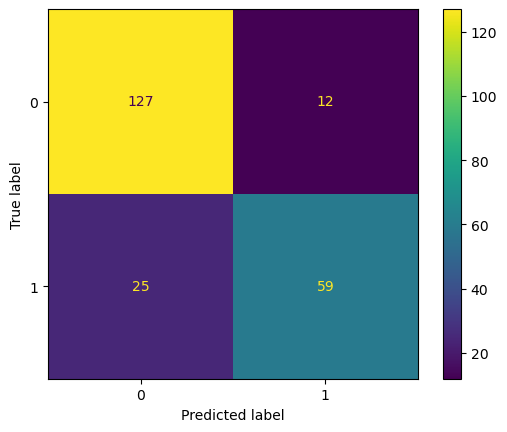

In [92]:
def conf_matrix_plot(model, x_data, y_data):
	'''
	Accepts as argument model object, X data (test or validate), and y data (test or validate). 
	Returns a plot of confusion matrix for predictions on y data.
	''' 
  
	model_pred = model.predict(x_data)
	cm = confusion_matrix(y_data, model_pred, labels=model.classes_)
	disp = ConfusionMatrixDisplay(confusion_matrix=cm,
							 display_labels=model.classes_)
  
	disp.plot(values_format='')  # `values_format=''` suppresses scientific notation
	plt.show()

# Generate confusion matrix
conf_matrix_plot(rf_val, X_val, y_val)

Here is the accuracy, the accuracy against the validation data should perform similiarly against the test dataset for the submission.

In [93]:
# Accuracy of rf_val on the validation set
rf_val.score(X_val, y_val)  

0.7612903225806451

The model seems to be functioning within a acceptable accuracy. I will now create run predictions on the test data and create the submission csv

# Step 6 Submission

I need some help in order to format the prediction to the desired format, so I am taking some guidance from [Titanic Tutorial](https://www.kaggle.com/code/alexisbcook/titanic-tutorial#Load-the-data)


In [94]:
# Load in the test data
test_data = pd.read_csv("test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [95]:
#Examine the columns for the test data
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


Format the test data the same as the training data

In [96]:
#Make a new DataFrame for X_test
X_test = test_data.copy()

#Create the Age_listed column 
X_test["Age_listed"] = X_test["Age"].notna().astype(int)

# assign the missing values to the mean age of the dataset rounded to the nearest whole number
X_test["Age"] = X_test["Age"].fillna(round(X_test["Age"].mean()))

# Create a dummy variable in the dataframe for the cabin column
X_test["Cabin_listed"] = X_test["Cabin"].notna().astype(int)

# assign the missing values to the most common embarked
X_test["Embarked"] = X_test["Embarked"].fillna(X_test["Embarked"].mode()[0])

#Create a dummy variable for the Sex and Embarked columns in the dataframe
X_test = pd.get_dummies(X_test, columns=["Sex", "Embarked"], drop_first=True, dtype=int)

#Drop the Cabin, Name, Ticket, and passengerId columns
X_test = X_test.drop(["Cabin", "Name", "Ticket", "PassengerId"], axis=1)

#Confirmation of columns
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Pclass        418 non-null    int64  
 1   Age           418 non-null    float64
 2   SibSp         418 non-null    int64  
 3   Parch         418 non-null    int64  
 4   Fare          417 non-null    float64
 5   Age_listed    418 non-null    int32  
 6   Cabin_listed  418 non-null    int32  
 7   Sex_male      418 non-null    int32  
 8   Embarked_Q    418 non-null    int32  
 9   Embarked_S    418 non-null    int32  
dtypes: float64(2), int32(5), int64(3)
memory usage: 24.6 KB


Create a Submission File

In [97]:
# Make predictions
predictions = rf_val.predict(X_test)

# Create an output dataframe
output = pd.DataFrame({"PassengerId": test_data["PassengerId"], "Survived": predictions})
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!
